# Predicción de Desarrollo Personal en Personas con Discapacidad

### 1. Resumen Ejecutivo y Objetivo
El objetivo principal de este proyecto es construir un pipeline de Machine Learning capaz de predecir o clasificar si una persona con discapacidad considera que su condición ha sido un factor que **ayudó o forjó su desarrollo personal** (Impresión Positiva). 
Entender los factores socio-demográficos (como la edad, el acceso a servicios de salud y el entorno social) que contribuyen a la resiliencia y superación personal es vital para el diseño de políticas públicas y programas de apoyo más efectivos.

In [1]:
import pandas as pd
import os
from dbfread import DBF
import numpy as np

import math

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score , auc

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV

from sklearn import metrics 
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay

from sklearn import set_config
set_config(transform_output="pandas")


In [2]:
# ==========================================
# CONFIGURACIÓN GLOBAL DE ESTILOS VISUALES
# ==========================================
# 1. Color de Fondo 
COLOR_FONDO = '#E8E1D5'
plt.rcParams['figure.facecolor'] = COLOR_FONDO
plt.rcParams['axes.facecolor'] = COLOR_FONDO
# 2. Paleta de colores secuenciales base (Tonos Salmón/Tierra)

PALETA_PRINCIPAL = "Reds_d" # El degradado que ves en las barras
COLOR_TITULAR = "#D38B7C"   # El color salmón de la primera barra para gráficos de un solo color

# 3. Quitar bordes y agregar cuadrícula predeterminada
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid.axis'] = 'x'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5

In [3]:
#Importacion de los datos

data_general       = pd.DataFrame(DBF('Data/CAP_100_DISCAPACIDAD.dbf', load=True, encoding='latin-1'))
data_discapacidad  = pd.DataFrame(DBF('Data/CAP_200_DISCAPACIDAD.dbf', load=True, encoding='latin-1'))
data_vivienda      = pd.DataFrame(DBF('Data/CAP_300_HOGAR Y VIVIENDA.dbf', load=True, encoding='latin-1'))
data_educacion     = pd.DataFrame(DBF('Data/CAP_500_EDUCACION.dbf', load=True, encoding='latin-1'))
data_salud         = pd.DataFrame(DBF('Data/CAP_600_SALUD.dbf', load=True, encoding='latin-1'))
data_empleo1       = pd.DataFrame(DBF('Data/CAP_700_EMPLEO_1.dbf', load=True, encoding='latin-1'))
data_empleo2       = pd.DataFrame(DBF('Data/CAP_700_EMPLEO_2.dbf', load=True, encoding='latin-1'))
data_accesibilidad = pd.DataFrame(DBF('Data/CAP_800_ACCESIBILIDAD.dbf', load=True, encoding='latin-1'))
data_integracion   = pd.DataFrame(DBF('Data/CAP_900_INTEGRACION.dbf', load=True, encoding='latin-1'))

Renombramos las columnas de los datasets para una mayor comprensión.

In [4]:
nombre_general = {
    'NOMBREDD':'departamento',    
    'P103':'parentesco', 
    'P105':'sexo',
    'P106':'edad', 
    'P108':'estadocivil', 
    'P109_1':'estudio', 
} 

In [5]:
nombre_discapacidad = {
    'P203':'movilidad',
    'P204':'vision',
    'P205':'comunicacion',
    'P206':'audicion',
    'P207':'cognitivo',
    'P208':'social',
    'P209':'cronico'
}

In [6]:
nombre_accesibilidad = {
    'P802_01':'salud',
    'P802_02':'educativo',
    'P802_04':'farmacia',
    'P802_05':'spub',
    'P802_11':'mercado',
    'P802_12':'super',
    'P806_01':'transportepublicod',
    'P806_09':'aereo',
    'P808':'estadovias'    
}


In [7]:
nombre_educacion = {
    'P501':'lee', 
    'P502':'asisteestablecimiento', 
    'P509':'xqno', 
    'P523':'etnia' 
}

In [8]:
nombre_salud = {
    'P601_3':'sintonmacronico',
    'P601_4':'accidente',
    'P621':'hijos',
    'P619':'segurodesalud',
    'P606':'presenciasintomadisc'
}

In [9]:
nombre_integracion = {
    'P901':'tratodist',
    'P905':'relacionsentimentalpas',
    'P911':'voto',
    'P921_2':'impdesarrollopersonal',
    'P921_3':'valoracosas'
}

In [10]:
data_empleo1 = data_empleo1.replace('', np.nan)
nombre_empleo = {
    'P735':'quieretrabajar',
    'P744':'discpentrabajo',
    'P734':'quehizosempas',
    'P701':'trabajoultsemana',
    'P702':'volvera',
    'P703':'negocio',
}

In [11]:
#renombrar columnas 
data_general.rename(columns=nombre_general,inplace=True)
data_discapacidad.rename(columns=nombre_general,inplace=True)
data_vivienda.rename(columns=nombre_general,inplace=True)
data_educacion.rename(columns=nombre_general,inplace=True)
data_salud.rename(columns=nombre_general,inplace=True)
data_empleo1.rename(columns=nombre_general,inplace=True)
data_empleo2.rename(columns=nombre_general,inplace=True)
data_accesibilidad.rename(columns=nombre_general,inplace=True)
data_integracion.rename(columns=nombre_general,inplace=True)
data_discapacidad.rename(columns=nombre_discapacidad,inplace=True)
data_accesibilidad.rename(columns=nombre_accesibilidad,inplace=True)
data_empleo1.rename(columns=nombre_empleo,inplace=True)
data_integracion.rename(columns=nombre_integracion,inplace=True)
data_salud.rename(columns=nombre_salud,inplace=True)
data_educacion.rename(columns=nombre_educacion,inplace=True)

In [12]:
dataset = pd.concat([
    data_general[list(nombre_general.values())], 
    data_empleo1[list(nombre_empleo.values())], 
    data_integracion[list(nombre_integracion.values())],
    data_salud[list(nombre_salud.values())], 
    data_educacion[list(nombre_educacion.values())], 
    data_accesibilidad[list(nombre_accesibilidad.values())],
    data_discapacidad[list(nombre_discapacidad.values())]  
], axis=1)

Definimos una funcion que grafique las distintas metricas del modelo.

In [13]:
def evaluar_modelo(pipeline_entrenado, X_test, y_test, nombre_modelo="Modelo"):
    """
    Genera predicciones sobre X_test y muestra visualmente:
    1. Resumen de métricas (Classification Report como texto)
    2. Matriz de confusión.
    3. Curva ROC-AUC.
    """
    # Predicciones
    y_pred = pipeline_entrenado.predict(X_test)
    
    # Intentar obtener probabilidades para AUC
    try:
        y_prob = pipeline_entrenado.predict_proba(X_test)[:, 1]
        has_proba = True
    except AttributeError:
        has_proba = False
        print(f"El modelo {nombre_modelo} no soporta predict_proba. Omitiendo curva ROC.")
    
    # 1. Resumen de Métricas (Classification Report)
    print(f"\n--- Evaluación: {nombre_modelo} ---")
    print(classification_report(y_test, y_pred))
    
    # Configuración de los gráficos
    if has_proba:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax_cm = axes[0]
        ax_roc = axes[1]
    else:
        fig, ax_cm = plt.subplots(1, 1, figsize=(7, 5))
        
    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax_cm, cbar=False)
    ax_cm.set_title('Matriz de Confusión')
    ax_cm.set_xlabel('Predicción')
    ax_cm.set_ylabel('Real')
    
    # 3. Curva ROC-AUC
    if has_proba:
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        ax_roc.plot(fpr, tpr, color='#8B3A3A', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        ax_roc.plot([0, 1], [0, 1], color='#333333', lw=2, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)')
        ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
        ax_roc.set_title('Curva ROC')
        ax_roc.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

Graficas para el Random forest que nos permite tener interpretabilidad del modelo (featured importance y partial dependace plot). 

In [14]:
def graficar_importancia_variables(pipeline_entrenado, top_n=10, nombre_modelo="Random Forest"):
    """
    Extrae la importancia de las variables del modelo Random Forest dentro del pipeline,
    reconstruye los nombres de las columnas verdaderas después del preprocesamiento,
    y genera un gráfico de barras horizontales con las variables más importantes.
    """
    print(f"Generando gráfico de importancia de variables para {nombre_modelo}...")
    
    # 1. Extraer el modelo y el preprocesador del pipeline final

    modelo = pipeline_entrenado.named_steps['clasificador']
    preprocesador = pipeline_entrenado.named_steps['preprocesado_datos']
    
    # Verificar si el modelo tiene la propiedad de importancia
    if not hasattr(modelo, "feature_importances_"):
        print(f"Error: El modelo {nombre_modelo} no tiene el atributo 'feature_importances_'.")
        print("Este gráfico es principalmente para Random Forest, Decision Trees o XGBoost.")
        return
        
    importancias = modelo.feature_importances_
    
    # 2. Reconstruir los nombres de las columnas de salida del preprocesador

    
    # Obtenemos los nombres de las columnas de cada transformador
    nombres_features = []
    
    # Recorremos los transformadores (num y cat)
    for nombre, trans, descritas in preprocesador.transformers_:
        if nombre == 'remainder':
            continue
            
        if nombre == 'num':
            # Las numéricas conservan sus nombres originales
            nombres_features.extend(descritas)
            
        elif nombre == 'cat':
            # Para las categóricas, necesitamos sacar los nombres del OneHotEncoder
            # Accedemos al OneHotEncoder dentro del pipeline 'cat'
            if hasattr(trans, 'named_steps') and 'onehot' in trans.named_steps:
                ohe = trans.named_steps['onehot']
            
                nombres_cat = ohe.get_feature_names_out(descritas)
                nombres_features.extend(nombres_cat)
            else:
                nombres_features.extend(descritas)
                
    # Verificación de seguridad
    if len(nombres_features) != len(importancias):
       print(f"Advertencia: No coincide la cantidad de nombres ({len(nombres_features)}) con importancias ({len(importancias)}).")
       nombres_features = [f"Feature {i}" for i in range(len(importancias))]

    # 3. Crear DataFrame para organizar los datos
    df_importancia = pd.DataFrame({
        'Variable': nombres_features,
        'Importancia': importancias
    })
    
    # Ordenar de mayor a menor importancia y tomar el Top N
    df_top = df_importancia.sort_values(by='Importancia', ascending=False).head(top_n)
    
    # 4. Configurar y generar el gráfico
    plt.figure(figsize=(10, 6))
    
    # Usar una paleta de colores rojos/marrones oscuros similar a la solicitada
    # seaborn.color_palette("Reds_d", n_colors=top_n) proporciona ese degradado
    sns.barplot(
        x='Importancia', 
        y='Variable', 
        data=df_top, 
        palette=sns.color_palette("Reds_d", n_colors=top_n)
    )
    
    plt.title(f'Top {top_n} Variables más Importantes\n{nombre_modelo}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.ylabel('')
    
    # Configurar estilo visual similar a la imagen (fondo color crema/arena)
    ax = plt.gca()
    ax.set_facecolor('#E8E1D5')  # Color arena claro para el fondo del gráfico principal
    fig = plt.gcf()
    fig.patch.set_facecolor('#E8E1D5') # Color arena claro para el borde exterior
    
    # Eliminar bordes superior y derecho (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Agregar líneas de cuadrícula verticales sutiles
    ax.grid(axis='x', linestyle='-', alpha=0.5, color='gray')
    ax.set_axisbelow(True) # Para que las rayas queden detrás de las barras
    
    # Negrita en las etiquetas del eje Y
    plt.yticks(fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def graficar_pdp(pipeline_entrenado, X_train, features, nombre_modelo="Random Forest"):
    """
    Genera gráficos de Dependencia Parcial (PDP) para las características especificadas.
    Muestra cómo el cambio de una variable específica afecta la probabilidad de predecir la clase positiva.
    
    Parámetros:
    - pipeline_entrenado: Tu modelo ya entrenado (con .fit() aplicado).
    - X_train: Datos de entrenamiento originales limpios (pandas DataFrame).
    - features: Lista de nombres de columnas o índices a analizar. Ej: ['edad', 'hijos'].
    """
    
    # Creamos el lienzo del gráfico ajustando el tamaño según la cantidad de variables
    num_features = len(features)
    fig, ax = plt.subplots(figsize=(12, 5 * num_features))
    
    # Usamos from_estimator: la ventaja del Pipeline es que le pasamos el X_train original
    # y él se encarga de aplicar todo el preprocesamiento (escalado, imputación, one-hot)
    # antes de probar las distintas combinaciones en el Random Forest.
    PartialDependenceDisplay.from_estimator(
        estimator=pipeline_entrenado,
        X=X_train,
        features=features,
        kind="average", 
        ax=ax,
        n_jobs=-1,      
        pd_line_kw={'color': '#D38B7C', 'linewidth': 3} 
    )
    
    fig.suptitle(f'Dependencia Parcial (PDP) - {nombre_modelo}', fontsize=16)
    plt.tight_layout()
    fig.subplots_adjust(top=0.90) 
    plt.show()




Análisis exploratorio de datos (EDA) para visualizar los datos faltantes de las distintas variables.

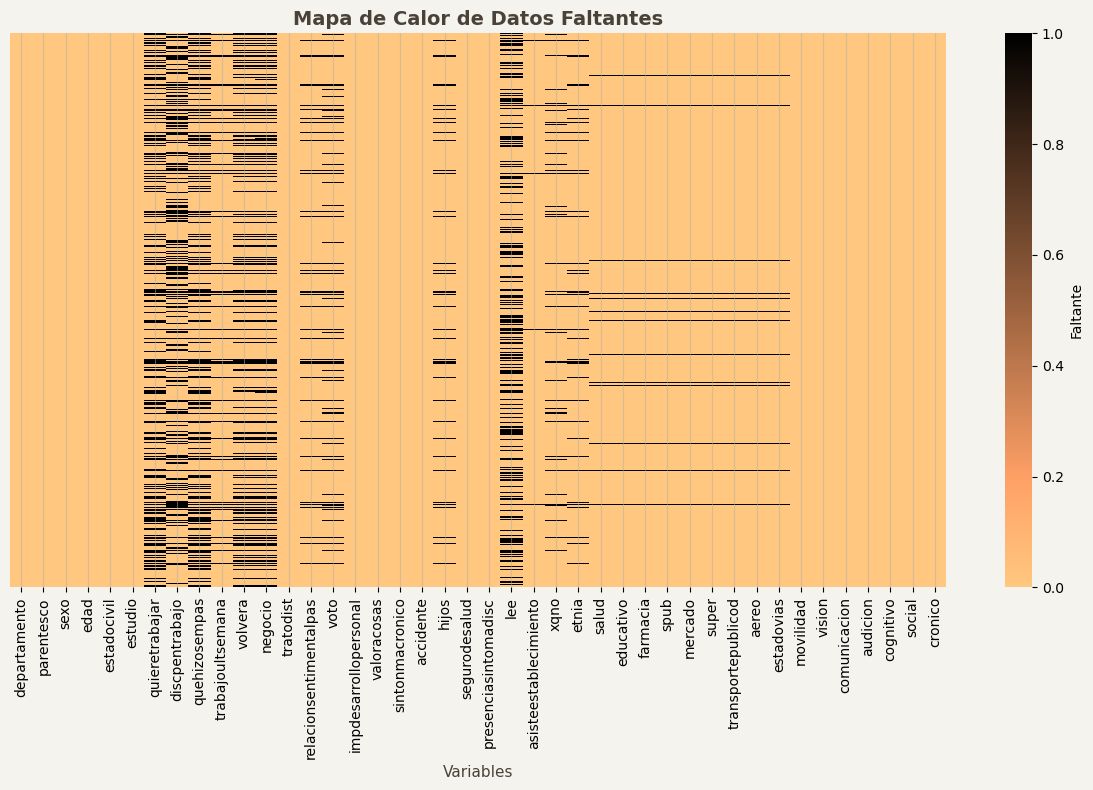

C:\Users\Rafael\AppData\Local\Temp\ipykernel_2300\1671029431.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Porcentaje', y='Variable',


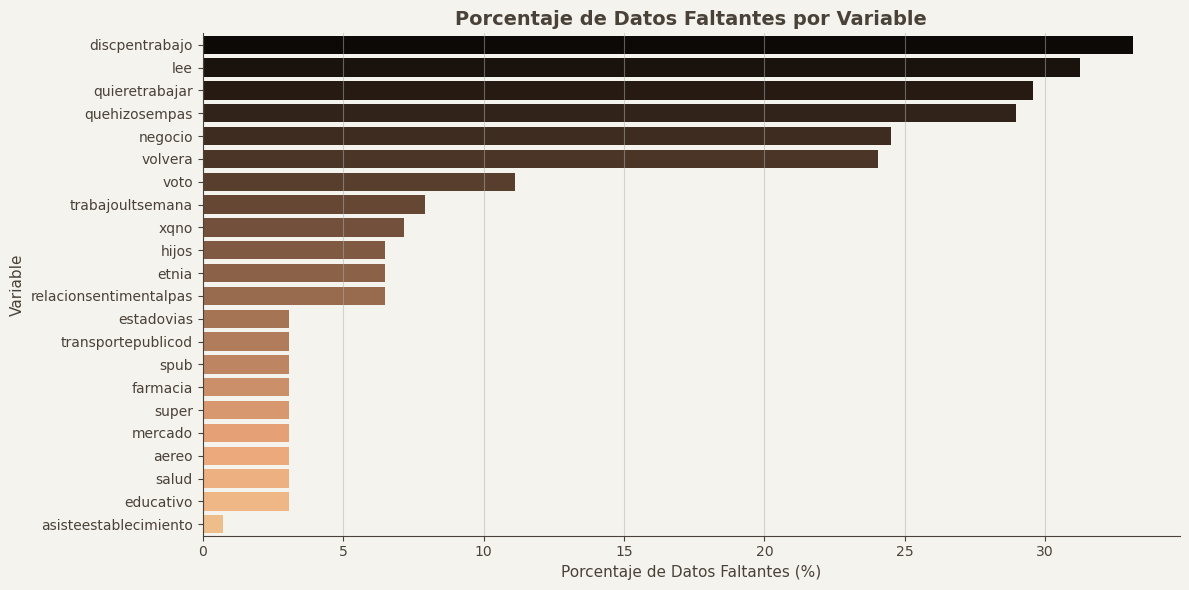


RESUMEN DE DATOS FALTANTES
              Variable  Valores Faltantes  Porcentaje
        discpentrabajo              12435   33.138791
                   lee              11726   31.249334
        quieretrabajar              11096   29.570408
         quehizosempas              10869   28.965462
               negocio               9197   24.509647
               volvera               9021   24.040614
                  voto               4170   11.112888
      trabajoultsemana               2975    7.928259
                  xqno               2693    7.176740
                 hijos               2431    6.478520
                 etnia               2431    6.478520
relacionsentimentalpas               2431    6.478520
            estadovias               1158    3.086025
    transportepublicod               1158    3.086025
                  spub               1158    3.086025
              farmacia               1158    3.086025
                 super               1158    3.086025


In [15]:
# Calcular porcentaje de valores faltantes por columna
missing_data = dataset.isnull().sum()
missing_percent = (missing_data / len(dataset)) * 100
missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Valores Faltantes': missing_data.values,
    'Porcentaje': missing_percent.values
}).sort_values('Valores Faltantes', ascending=False)

# Filtrar solo columnas con datos faltantes
missing_df = missing_df[missing_df['Valores Faltantes'] > 0]

# Color de fondo beige/crema
bg_color = '#F5F3EE'

# Visualización 1: Heatmap de datos faltantes
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

sns.heatmap(dataset.isnull(), cbar=True, yticklabels=False, 
            cmap='copper_r', ax=ax, cbar_kws={'label': 'Faltante'})
plt.title('Mapa de Calor de Datos Faltantes', fontsize=14, fontweight='bold', color='#4A4238')
plt.xlabel('Variables', fontsize=11, color='#4A4238')
plt.tight_layout()
plt.show()

# Visualización 2: Barplot con paleta que combina
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)
    
    # Paleta de tonos tierra/cálidos que combinan con beige
    sns.barplot(data=missing_df, x='Porcentaje', y='Variable', 
                palette='copper', ax=ax)
    
    plt.xlabel('Porcentaje de Datos Faltantes (%)', fontsize=11, color='#4A4238')
    plt.ylabel('Variable', fontsize=11, color='#4A4238')
    plt.title('Porcentaje de Datos Faltantes por Variable', 
              fontsize=14, fontweight='bold', color='#4A4238')
    
    # Personalizar ejes
    ax.tick_params(colors='#4A4238')
    ax.spines['bottom'].set_color('#4A4238')
    ax.spines['left'].set_color('#4A4238')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla resumen
    print("\n" + "="*60)
    print("RESUMEN DE DATOS FALTANTES")
    print("="*60)
    print(missing_df.to_string(index=False))
else:
    print("¡No hay datos faltantes en el dataset!")

Analizamos la variable objetio y eliminamos aquellos individuos que no respondieron.

In [16]:
dataset['impdesarrollopersonal'].value_counts()

impdesarrollopersonal
1    20416
2    16919
9      189
Name: count, dtype: int64

In [17]:
dataset_filtrado = dataset[dataset['impdesarrollopersonal'] != 9]

In [18]:
dataset_filtrado['impdesarrollopersonal'].value_counts()

impdesarrollopersonal
1    20416
2    16919
Name: count, dtype: int64

In [19]:
dataset_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37335 entries, 0 to 37523
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   departamento            37335 non-null  object 
 1   parentesco              37335 non-null  int64  
 2   sexo                    37335 non-null  object 
 3   edad                    37335 non-null  int64  
 4   estadocivil             37335 non-null  object 
 5   estudio                 37335 non-null  object 
 6   quieretrabajar          26293 non-null  float64
 7   discpentrabajo          24960 non-null  float64
 8   quehizosempas           26517 non-null  float64
 9   trabajoultsemana        34394 non-null  float64
 10  volvera                 28357 non-null  float64
 11  negocio                 28181 non-null  float64
 12  tratodist               37335 non-null  int64  
 13  relacionsentimentalpas  34935 non-null  float64
 14  voto                    33203 non-null  flo

Train Test Split (con estratificación para mantener proporciones en 'y') y eliminar el leakage de datos.

In [20]:
y = dataset_filtrado['impdesarrollopersonal']
y = (dataset_filtrado['impdesarrollopersonal'] == 1).astype(int)
X = dataset_filtrado.drop('impdesarrollopersonal', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y )

Se realizó el preprocesamiento de valores faltantes mediante la creación de un componente personalizado. Este componente aplica imputaciones basadas en reglas lógicas del negocio (por ejemplo, imputar variables condicionadas por la edad). Posteriormente, este paso se integró al preprocesador general para ensamblar un Pipeline completo.

In [21]:
# ==============================================================================
# 1. Transformador Personalizado (Custom Transformer)
# ==============================================================================
class LogicaNegocioTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        if 'lee' in X.columns and 'edad' in X.columns:
            premedios = X.groupby('edad')['lee'].mean()
            self.prob_de_ser_2_ = premedios - 1
        else:
            self.prob_de_ser_2_ = None
            
        return self
        
    def transform(self, X):
        X_copy = X.copy()
        
        
        # Lógica basada en la edad
        if 'edad' in X_copy.columns:
            if 'estadocivil' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 12, 'estadocivil'] = 0
            if 'estudio' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 5, 'estudio'] = 1
            if 'lee' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 5, 'lee'] = 2
            if 'xqno' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 5, 'xqno'] = 0
            if 'quieretrabajar' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 14, 'quieretrabajar'] = 0
            if 'discpentrabajo' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 14, 'discpentrabajo'] = 0
            if 'voto' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 18, 'voto'] = 0
            if 'hijos' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 12, 'hijos'] = 2
            if 'relacionsentimentalpas' in X_copy.columns:    
                X_copy.loc[X_copy['edad'] < 12, 'relacionsentimentalpas'] = 0
            if 'etnia' in X_copy.columns:
                X_copy.loc[X_copy['edad'] < 12, 'etnia'] = 0
                
        # Rellenar valores nulos por defecto en columnas específicas
        if 'volvera' in X_copy.columns:
            X_copy['volvera'] = X_copy['volvera'].fillna(0)
        if 'negocio' in X_copy.columns:
            X_copy['negocio'] = X_copy['negocio'].fillna(0)
            
        # Lógica basada en otras columnas
        if 'trabajoultsemana' in X_copy.columns:
            if 'quieretrabajar' in X_copy.columns:
                X_copy.loc[X_copy['trabajoultsemana'] == 1, 'quieretrabajar'] = 0
            if 'quehizosempas' in X_copy.columns:
                X_copy.loc[X_copy['trabajoultsemana'] == 1, 'quehizosempas'] = 0
                
        if 'asisteestablecimiento' in X_copy.columns and 'xqno' in X_copy.columns:
            X_copy.loc[X_copy['asisteestablecimiento'] == 1, 'xqno'] = 0
            
        if 'relacionsentimentalpas' in X_copy.columns:
            X_copy.loc[X_copy['relacionsentimentalpas'] == 9, 'relacionsentimentalpas'] = np.nan
            
        # --- Imputación probabilística de 'lee' ---
        if hasattr(self, 'prob_de_ser_2_') and self.prob_de_ser_2_ is not None:
            if 'lee' in X_copy.columns and 'edad' in X_copy.columns:
                filas_nan = X_copy['lee'].isna()
                n_nans = filas_nan.sum()
                if n_nans > 0:
                    probabilidades_nan = X_copy.loc[filas_nan, 'edad'].map(self.prob_de_ser_2_).fillna(0.5)
                    aleatorios = np.random.rand(n_nans)
                    nuevos_valores = np.where(aleatorios < probabilidades_nan, 2, 1)
                    X_copy.loc[filas_nan, 'lee'] = nuevos_valores
        # Convertir a numérico solo a las columnas que REALMENTE lo necesitan
        cols_to_numeric = ['quieretrabajar', 'discpentrabajo', 'estudio'] 
        for col in cols_to_numeric:
            if col in X_copy.columns:
                X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
                
        return X_copy
# ==============================================================================
# 2. Creación del Preprocesador (ColumnTransformer)
# ==============================================================================


def to_string_func(X):
    return X.astype(str)
to_string_transformer = FunctionTransformer(to_string_func)
def crear_preprocesador(variables_categoricas, variables_numericas):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        # 1. Forzamos a que todo sea texto antes de imputar
        ('to_string', to_string_transformer),
        # 2. Ahora rellenamos vacíos con la palabra 'missing' de forma segura
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        # 3. Y aplicamos OneHotEncoder (ahora sí verá 'departamento')
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, variables_numericas),
            ('cat', categorical_transformer, variables_categoricas)
        ],
        remainder='drop' 
    )
    return preprocessor
# ==============================================================================
# 3. Flujo Total: Integración en un Único Gran Pipeline
# ==============================================================================
def construir_pipeline_completo(variables_categoricas, variables_numericas, modelo):
    preprocesador_sklearn = crear_preprocesador(variables_categoricas, variables_numericas)
    
    pipeline_final = Pipeline(steps=[
        ('logica_negocio', LogicaNegocioTransformer()),
        ('preprocesado_datos', preprocesador_sklearn), 
        ('clasificador', modelo)                        
    ])
    
    return pipeline_final

Seleccionamos las variables categoricas y las numericas.

In [23]:
variables_numericas = ['edad']
variables_categoricas = [col for col in X.columns if col not in variables_numericas]

Se realizó el entrenamiento de los tres modelos propuestos (Regresión Logística, Random Forest y KNN) utilizando sus hiperparámetros por defecto. El objetivo de esta fase fue establecer un 'Baseline' (Línea Base) de rendimiento que nos permitiera comparar las futuras optimizaciones. 

c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.72      0.62      0.67      5076
           1       0.72      0.80      0.76      6125

    accuracy                           0.72     11201
   macro avg       0.72      0.71      0.71     11201
weighted avg       0.72      0.72      0.72     11201



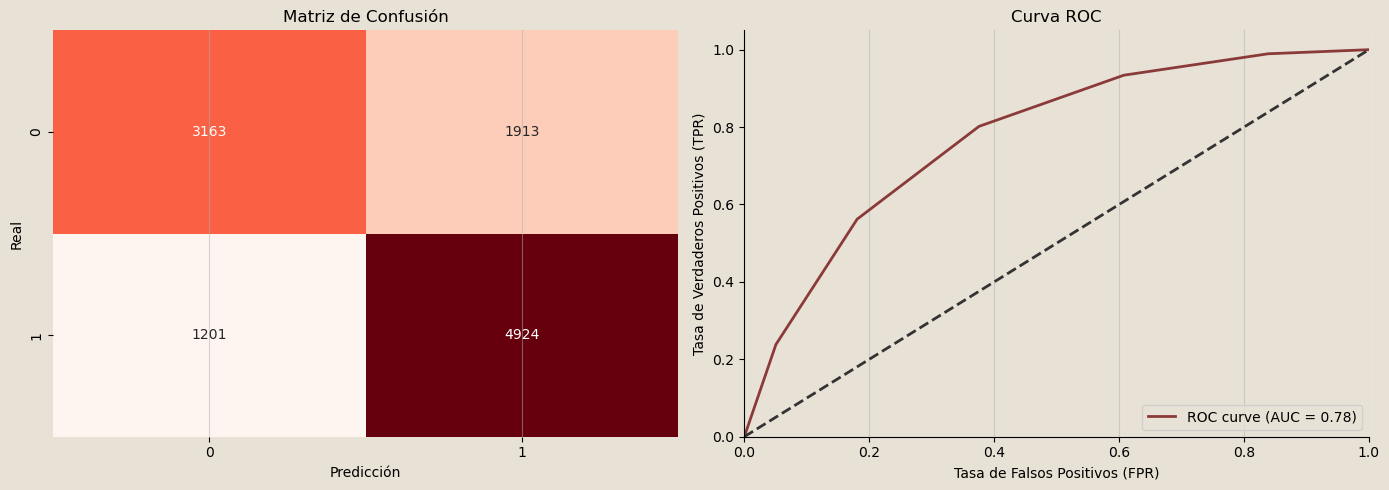

In [ ]:
pipeline_knn = construir_pipeline_completo(
    variables_categoricas, 
    variables_numericas, 
    KNeighborsClassifier()
)
# 2. Entrenar el modelo
pipeline_knn.fit(X_train, y_train)
# 3. evaluamos las  metricas
evaluar_modelo(pipeline_knn, X_test, y_test, nombre_modelo="KNN")

KNN sufre con la dimensionalidad, bajando el AUC a 0.78

c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.92      0.66      0.77      5076
           1       0.77      0.95      0.85      6125

    accuracy                           0.82     11201
   macro avg       0.84      0.80      0.81     11201
weighted avg       0.84      0.82      0.81     11201



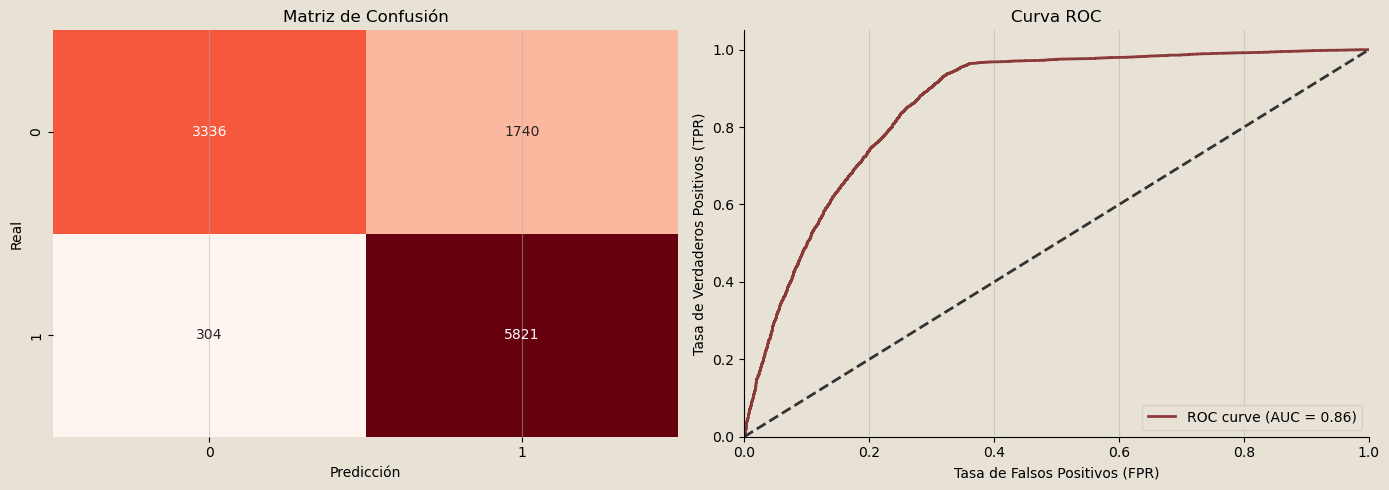

In [25]:
pipeline_lr = construir_pipeline_completo(
    variables_categoricas, 
    variables_numericas, 
    LogisticRegression(max_iter=1000, random_state=42)
)

# 2. Entrenar el modelo
pipeline_lr.fit(X_train, y_train)

# 3. evaluamos las  metricas
evaluar_modelo(pipeline_lr, X_test, y_test, nombre_modelo="Regresión Logística") 

La Regresión Logística logra un AUC de 0.86, sirviendo como un piso mínimo aceptable.

c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      5076
           1       0.78      0.94      0.85      6125

    accuracy                           0.82     11201
   macro avg       0.84      0.81      0.82     11201
weighted avg       0.84      0.82      0.82     11201



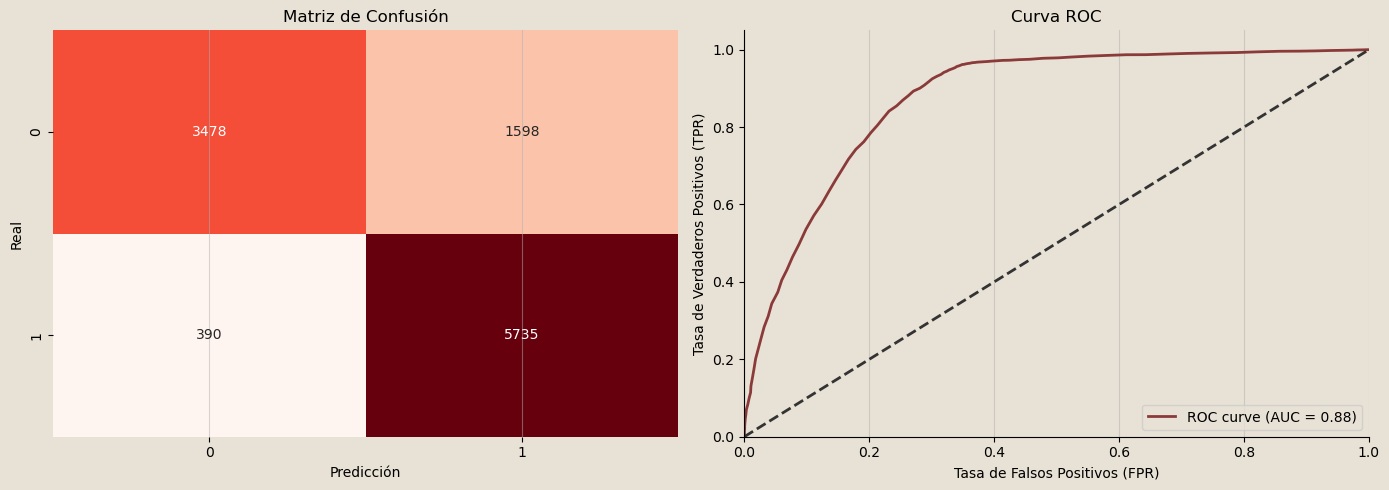

In [ ]:
# 1. Crear el pipeline con la función
pipeline_rf = construir_pipeline_completo(
    variables_categoricas, 
    variables_numericas, 
    RandomForestClassifier(random_state=42)
)
# 2. Entrenar el modelo
pipeline_rf.fit(X_train, y_train)

# 3. evaluamos las  metricas
evaluar_modelo(pipeline_rf, X_test, y_test, nombre_modelo="Regresión Ramdom forest")

Random Forest domina con un AUC de 0.88, demostrando su capacidad para manejar variables categóricas complejas.

## Comparación de los Modelos Base
Tras evaluar los tres modelos propuestas con sus hiperparámetros por defecto, obtuvimos los siguientes resultados en el conjunto de prueba (Test):
*   **Regresión Logística:** AUC 0.85
*   **K-Nearest Neighbors:** AUC 0.82
*   **Random Forest:** AUC 0.88.

**Decisión:** 
El modelo de Random Forest no solo superó a los demás algoritmos en el área bajo la curva (AUC), sino que su arquitectura de ensamble basada en árboles es teóricamente superior para manejar las múltiples variables categóricas y relaciones no lineales (como la edad) presentes en la encuesta ENEDIS. 
Por consiguiente, seleccionamos a Random Forest como nuestro modelo estrella.

Una vez seleccionado el Random Forest como el mejor modelo base (Baseline), procederemos con la optimización de sus hiperparámetros. Utilizaremos validación cruzada mediante GridSearchCV para encontrar la configuración óptima, garantizando así un modelo final con mayor robustez y consistencia frente a datos desconocidos.

--- Iniciando Optimización de Random Forest ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores Hiperparámetros Encontrados: {'clasificador__max_depth': None, 'clasificador__min_samples_leaf': 1, 'clasificador__min_samples_split': 5, 'clasificador__n_estimators': 300}
Mejor Score (ROC-AUC) en Validación Cruzada: 0.8762

Evaluando el Mejor Random Forest en el set de Test...


c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Rafael\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



--- Evaluación: Random Forest Optimizado ---
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      5076
           1       0.78      0.95      0.85      6125

    accuracy                           0.82     11201
   macro avg       0.85      0.81      0.81     11201
weighted avg       0.84      0.82      0.82     11201



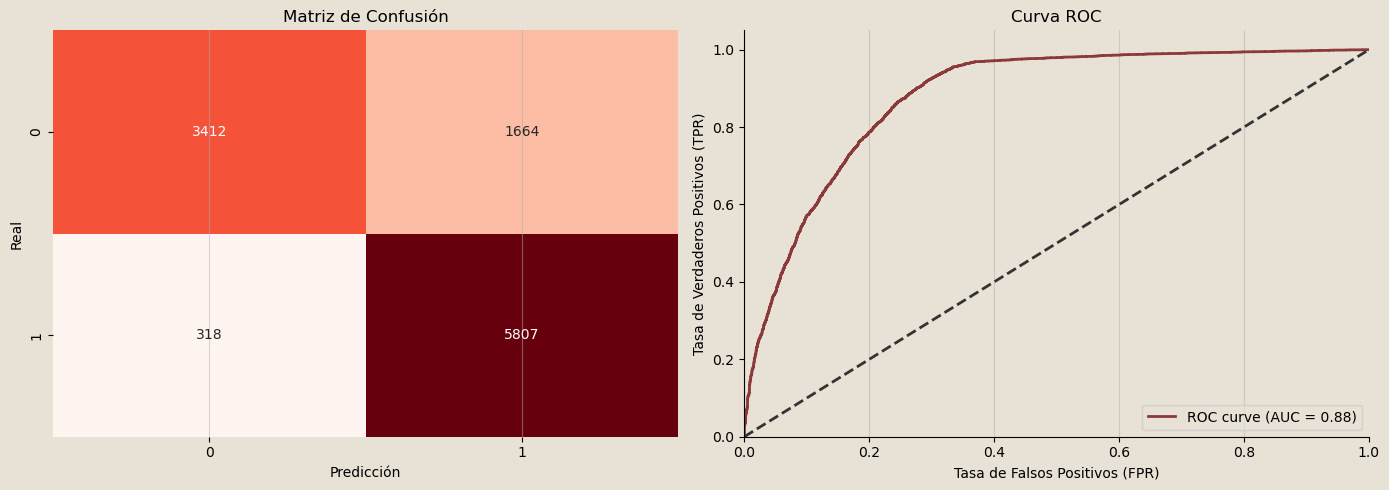

In [27]:
print("--- Iniciando Optimización de Random Forest ---")
# 1. Definimos la grilla de parámetros a probar

parametros_rf = {
    'clasificador__n_estimators': [100, 200, 300],          # Cuántos árboles creará el "bosque"
    'clasificador__max_depth': [None, 10, 20, 30],         # Profundidad máxima de los árboles
    'clasificador__min_samples_split': [2, 5, 10],         # Muestras mínimas requeridas para dividir un nodo interno
    'clasificador__min_samples_leaf': [1, 2, 4]            # Muestras mínimas requeridas para ser un nodo hoja final
}
# 2. Re-instanciamos nuestro pipeline base 
pipeline_base_rf = construir_pipeline_completo(variables_categoricas, variables_numericas, RandomForestClassifier(random_state=42))

# 3. Configuramos la Búsqueda en Grilla Estructurada (GridSearchCV)
grid_rf = GridSearchCV(
    estimator=pipeline_base_rf, # Pasamos el pipeline
    param_grid=parametros_rf,   # Qué combinaciones probar
    cv=5,                       # Validación Cruzada K-Fold de 5 cortes
    scoring='roc_auc',          # Queremos que optimice buscando el mejor AUC posible
    n_jobs=-1,                  
    verbose=2                  
)
# 4. Iniciar el entrenamiento en grilla 

grid_rf.fit(X_train, y_train)
# 5. Resultados de la optimización

print(f"Mejores Hiperparámetros Encontrados: {grid_rf.best_params_}")
print(f"Mejor Score (ROC-AUC) en Validación Cruzada: {grid_rf.best_score_:.4f}")
# 6. Almacenamos el mejor modelo encontrado (Scikit ya lo re-entrenó con X_train para ti)
mejor_pipeline_rf = grid_rf.best_estimator_
# 7. Finalmente, evaluamos este NUEVO SUPER MODELO con tu función de gráficos en los datos de Test (X_test)

print("\nEvaluando el Mejor Random Forest en el set de Test...")
evaluar_modelo(mejor_pipeline_rf, X_test, y_test, nombre_modelo="Random Forest Optimizado")

Luego de la optimización de los hiperparámetros mediante GridSearchCV, se observa que el modelo mantiene un rendimiento general (AUC 0.88) sumamente estable. La principal mejora radica en su calibración: el modelo optimizado redujo significativamente los Falsos Positivos (de 344 a 302), volviéndose más preciso al clasificar la clase negativa, a costa de un sacrificio marginal en la detección de Falsos Negativos.

Para dotar al modelo Random Forest de una mayor interpretabilidad, se desarrollaron dos visualizaciones clave: un análisis de Importancia de Variables (Feature Importance) para identificar los principales predictores, y un Gráfico de Dependencia Parcial (PDP) para comprender la incidencia y la forma del impacto de la variable fundamental 'edad' sobre nuestra predicción objetivo.

Generando gráfico de importancia de variables para Random Forest Optimizado...


C:\Users\Rafael\AppData\Local\Temp\ipykernel_2300\1982936220.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


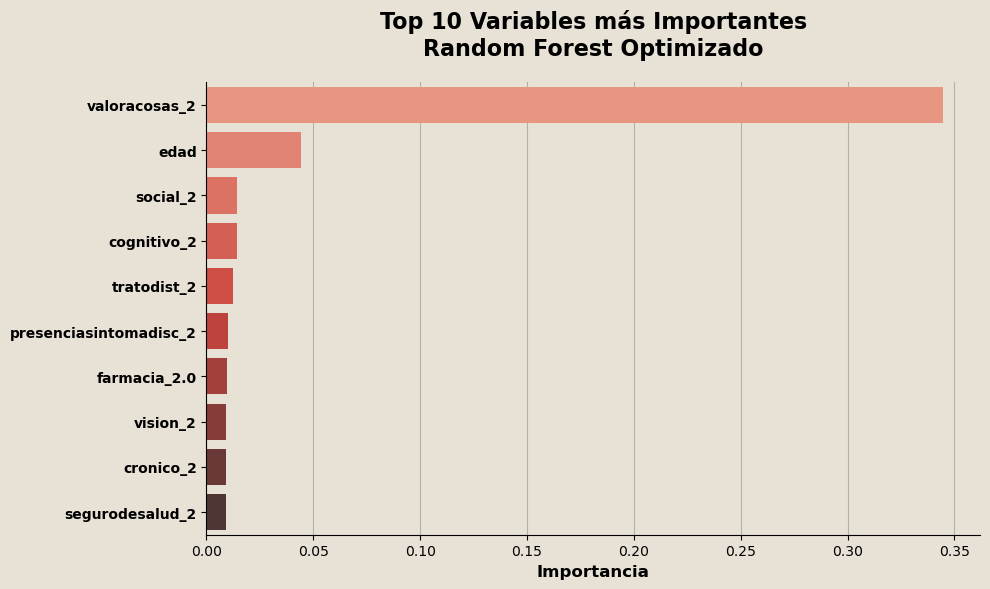

In [28]:
graficar_importancia_variables(mejor_pipeline_rf, top_n=10, nombre_modelo="Random Forest Optimizado")

A partir del grafico de importacia de las variables, se observa que el factor psicologio es una variable muy importante casi 10 veces mas que las otras.

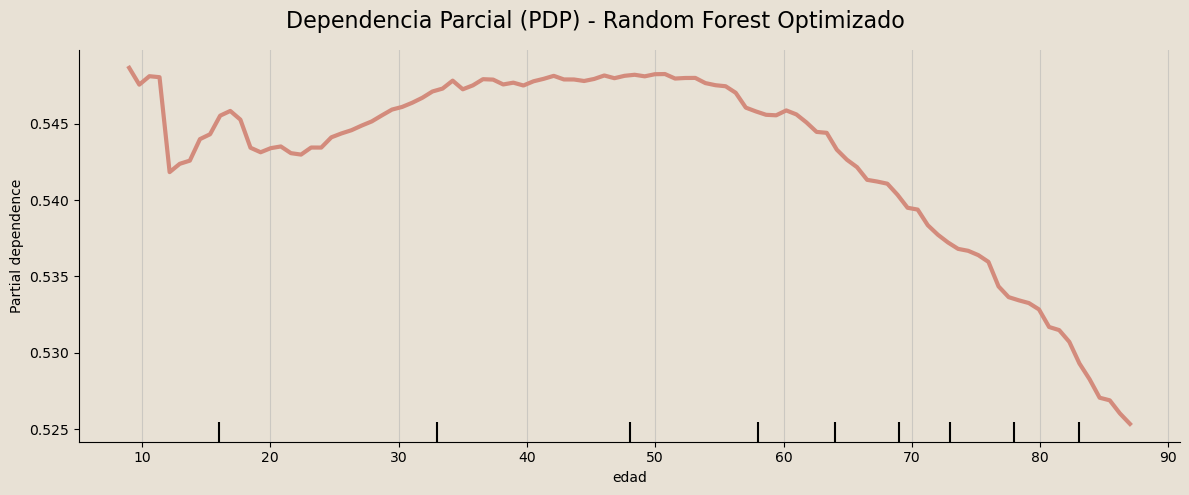

In [29]:
caracteristicas_a_analizar = ['edad'] 
graficar_pdp(mejor_pipeline_rf, X_train, caracteristicas_a_analizar, nombre_modelo="Random Forest Optimizado")

El Gráfico de Dependencia Parcial (PDP) revela una característica fundamental sobre cómo la edad impacta la percepción de resiliencia. En la primera infancia y hasta la adolescencia, se observa la menor probabilidad; esto sugiere que los individuos aún no poseen la autopercepción o madurez necesaria para considerar su discapacidad como un factor de desarrollo personal. Sin embargo, al llegar a la adultez media (30 a 50 años), la gráfica alcanza su pico máximo: los individuos en plena etapa productiva reflexionan sobre sus logros y barreras superadas, consolidando la percepción de que la discapacidad forjó un carácter vital para su desarrollo. Finalmente, al llegar a la vejez, la curva decae significativamente. Ya sea porque es la etapa donde estadísticamente se adquieren nuevas discapacidades, o porque el deterioro natural de la calidad de vida cambia las prioridades, la discapacidad deja de ser percibida como un motor de desarrollo personal.

Conclusión Final: El modelo demuestra algorítmicamente que la variable psicológica (valoracosas) tiene una injerencia predictiva casi 10 veces mayor que el tipo de discapacidad física padecida. Esto sugiere que las políticas públicas o de recursos humanos no solo deben enfocarse en los factores económicos, sino que también se debe priorizar intensamente la asistencia psicológica y el fortalecimiento de la autoestima como vehículo principal para lograr la integración real y el desarrollo personal